In [1]:
#Step 1 - load the data
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [4]:
X = df.drop("PE",axis = 1)
y = df["PE"]

In [5]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [6]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
# Split our data

In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,random_state = 42
)

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()

In [11]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Data -> Tensors

In [13]:
import torch 
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [14]:
# Tensor Dataset and DataLoader

In [15]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [16]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

### Deep Learning

In [18]:
# ANN model 

In [34]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
    #self refers to ANN class object
        self.model = nn.Sequential(
            # 1st hidden
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
            # 2nd hidden
            nn.Linear(6,6),
            nn.ReLU(),
            # output
            nn.Linear(6,1),
        )      
    def forward(self,x):
        return self.model(x)

In [35]:
import torch.optim as optim
model = ANN()

# loss,optimizers
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [36]:
# Train the ANN model 
train_losses = []
valid_losses = []

best_val_loss = float("inf")
epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #tot training loss for 1epoch
    for xb,yb in train_loader:
        #xb = features of 1 batch
        #yb = labels of 1 batch
        optimizer.zero_grad() # remove the prev stored gradients 
        outputs = model(xb)#forward prop ... predicted outputs
        loss = criterion(outputs,yb)#loss calculate
        loss.backward() #backward prop .. compute gradients
        optimizer.step() # params update

        running_loss+=loss.item() #loss is a tensor => py float
    epoch_train_loss = running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_valid_loss = 0.0

    with torch.no_grad(): # no gradient compute 
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs,yb)
            running_valid_loss+=loss
            
    epoch_val_loss = running_valid_loss/len(test_loader)
    valid_losses.append(epoch_val_loss)

    print(f"epoch ${epoch+1}/{epochs} ===> train loss = ${epoch_train_loss} & val loss = ${epoch_val_loss}")
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")

epoch $1/100 ===> train loss = $206272.90611979167 & val loss = $204729.828125
epoch $2/100 ===> train loss = $199853.55481770833 & val loss = $191161.421875
epoch $3/100 ===> train loss = $173401.333203125 & val loss = $151138.734375
epoch $4/100 ===> train loss = $126009.23141276042 & val loss = $101909.6328125
epoch $5/100 ===> train loss = $83094.86303710938 & val loss = $68160.171875
epoch $6/100 ===> train loss = $56650.98889973958 & val loss = $46999.33984375
epoch $7/100 ===> train loss = $37802.53360188802 & val loss = $29717.927734375
epoch $8/100 ===> train loss = $22634.766853841145 & val loss = $17056.798828125
epoch $9/100 ===> train loss = $12985.297786458334 & val loss = $10182.484375
epoch $10/100 ===> train loss = $8230.79047648112 & val loss = $7026.4423828125
epoch $11/100 ===> train loss = $5915.293184407552 & val loss = $5252.07080078125
epoch $12/100 ===> train loss = $4459.432971191406 & val loss = $3982.59912109375
epoch $13/100 ===> train loss = $3388.53169759

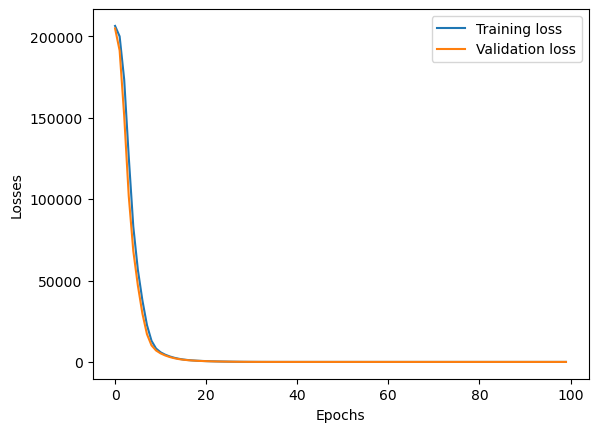

In [37]:
# plot losses
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training loss":train_losses,
    "Validation loss":valid_losses
})

plt.plot(loss_df["Training loss"],label = "Training loss")
plt.plot(loss_df["Validation loss"],label = "Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [38]:
# Loading best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [39]:
# Evaluate our model
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds,y_train_tensor)
    test_mse_loss = criterion(test_preds,y_test_tensor)

print("Training MSE",train_mse_loss.item())
print("Testing MSE",test_mse_loss.item())

Training MSE 21.085355758666992
Testing MSE 19.591876983642578


In [40]:
from sklearn.metrics import r2_score

print("r2 value",r2_score(y_test,test_preds))

r2 value 0.9315314520194707
